# Single-Input Distillation Ablation — Original Recipe (No Overfitting-Fix Bundle)
### DenseNet121 vs EfficientNet-B2 vs ResNet-50 vs VGG-16

**Why this notebook exists:** `single_input_distillation_comparison.ipynb` has a partial-unfreeze +
label-smoothing + extra-augmentation bundle backported from `three_input_coach_comparison.ipynb`.
That bundle was then tested in a clean, single-variable ablation on the three-input coach
(`three_input_ablation_original_recipe.ipynb`) and, separately, the ROI input itself was shown to
regress accuracy on all four architectures even under the *original* recipe. We never actually
tested whether the overfitting-fix bundle itself helps or hurts independent of ROI — and there's a
specific reason to suspect it might hurt here too: label smoothing changes the loss landscape, and
this notebook's early-stopping/checkpoint-selection logic keys off `val_loss`, not accuracy. If
label smoothing causes premature/wrong checkpoint picks (as suspected from the three-input coach
run, where EfficientNet-B2's best epoch dropped from 12 to 6 instead of increasing), that same
mechanism applies here regardless of ROI.

**This notebook changes exactly one thing back** versus `single_input_distillation_comparison.ipynb`:
Phase 2 uses full backbone unfreeze (not partial), the hard-label loss term has no label smoothing,
and augmentation is the original flip/rotation/color-jitter only (no `RandomAffine`,
no `RandomErasing`). The teacher, distillation loss structure (KL term), temperature (4.0), and
alpha (0.5) are unchanged — this isolates the overfitting-fix bundle's effect, not the distillation
approach itself.


In [1]:
# --- Install / import dependencies ---
import os, time, json, random, warnings, gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve,
)
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
print("PyTorch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())


PyTorch: 2.11.0+cu128 | CUDA available: True


In [2]:
# --- Load dataframes (same splits as architecture_comparison.ipynb) ---
train_df = pd.read_csv("../../dataframes/train_df_final.csv")
val_df   = pd.read_csv("../../dataframes/val_df_final.csv")
test_df  = pd.read_csv("../../dataframes/test_df_final.csv")

print("train:", len(train_df), "val:", len(val_df), "test:", len(test_df))


train: 2599 val: 328 test: 326


In [3]:
# --- Global configuration -- identical to architecture_comparison.ipynb, plus distillation params ---
# No LABEL_SMOOTHING, no UNFREEZE_PARAM_FRACTION -- this is the ablation without the fix bundle.
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
NUM_WORKERS = 4 if os.name != "nt" else 0

HEAD_WARMUP_EPOCHS = 5      # Phase 1: backbone frozen, head-only
MAX_EPOCHS = 40             # capped per-experiment budget (Phase 1 + Phase 2)
EARLY_STOPPING_PATIENCE = 8

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

FULL_PATH_COL = "full image cached path"
CROP_PATH_COL = "cropped image cached path"
LABEL_COL = "pathology"
CLASS_NAMES = ["Benign", "Malignant"]

BASELINE = dict(
    head_lr=1e-4,
    backbone_lr=1e-5,
    weight_decay=1e-4,
    scheduler="plateau",   # "plateau" | "cosine" | "onecycle"
)

# Knowledge-distillation hyperparameters (Hinton et al., 2015) -- unchanged from the non-ablation
# notebook, since distillation itself isn't what's being tested here.
DISTILL_TEMPERATURE = 4.0
DISTILL_ALPHA = 0.5   # weight on the soft (teacher) loss; (1 - alpha) weight on hard-label CE

ARCHITECTURES = ["densenet121", "resnet50", "efficientnet_b2", "vgg16"]
ARCH_DISPLAY_NAMES = {
    "densenet121": "DenseNet121",
    "resnet50": "ResNet-50",
    "efficientnet_b2": "EfficientNet-B2",
    "vgg16": "VGG-16",
}

RESULTS_DIR = "results"
CKPT_DIR = "checkpoints"   # same directory the dual-input teacher checkpoints already live in
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def free_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


In [4]:
# --- Label encoding, transforms, dataset -- original augmentation only, no RandomAffine/RandomErasing ---
def encode_label(raw_label):
    try:
        return int(raw_label)
    except (ValueError, TypeError):
        pass
    text = str(raw_label).strip().upper()
    return 1 if "MALIGNANT" in text else 0


train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class DualImageDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        full_image = Image.open(row[FULL_PATH_COL]).convert("RGB")
        cropped_image = Image.open(row[CROP_PATH_COL]).convert("RGB")
        full_image = self.transform(full_image)
        cropped_image = self.transform(cropped_image)
        label = torch.tensor(encode_label(row[LABEL_COL]), dtype=torch.long)
        return full_image, cropped_image, label


def make_loaders(batch_size=BATCH_SIZE):
    train_loader = DataLoader(
        DualImageDataset(train_df, train_transform), batch_size=batch_size,
        shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
    )
    val_loader = DataLoader(
        DualImageDataset(val_df, eval_transform), batch_size=batch_size,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=True,
    )
    test_loader = DataLoader(
        DualImageDataset(test_df, eval_transform), batch_size=batch_size,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=True,
    )
    return train_loader, val_loader, test_loader


## Teacher (dual-input, frozen) and student (single-input, full unfreeze in Phase 2) models

In [5]:
def build_backbone(arch):
    if arch == "densenet121":
        weights = models.DenseNet121_Weights.IMAGENET1K_V1
        base = models.densenet121(weights=weights)
        extractor = nn.Sequential(base.features, nn.ReLU(inplace=True), nn.AdaptiveAvgPool2d((1, 1)))
        dim = 1024
    elif arch == "resnet50":
        weights = models.ResNet50_Weights.IMAGENET1K_V2
        base = models.resnet50(weights=weights)
        extractor = nn.Sequential(*list(base.children())[:-1])
        dim = 2048
    elif arch == "efficientnet_b2":
        weights = models.EfficientNet_B2_Weights.IMAGENET1K_V1
        base = models.efficientnet_b2(weights=weights)
        extractor = nn.Sequential(base.features, nn.AdaptiveAvgPool2d((1, 1)))
        dim = 1408
    elif arch == "vgg16":
        weights = models.VGG16_Weights.IMAGENET1K_V1
        base = models.vgg16(weights=weights)
        extractor = nn.Sequential(base.features, nn.AdaptiveAvgPool2d((1, 1)))
        dim = 512
    else:
        raise ValueError(f"Unknown architecture: {arch}")
    return extractor, dim


class DualInputModel(nn.Module):
    """Teacher architecture — must match architecture_comparison.ipynb exactly to load its
    checkpoints."""

    def __init__(self, arch, num_classes=2, dropout=0.5):
        super().__init__()
        self.arch = arch
        self.full_extractor, feat_dim_full = build_backbone(arch)
        self.crop_extractor, feat_dim_crop = build_backbone(arch)
        combined_dim = feat_dim_full + feat_dim_crop
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 512), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(512, 128), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, full_image, cropped_image):
        full_feat = torch.flatten(self.full_extractor(full_image), 1)
        crop_feat = torch.flatten(self.crop_extractor(cropped_image), 1)
        combined = torch.cat([full_feat, crop_feat], dim=1)
        return self.classifier(combined)


def load_teacher(arch):
    """Loads the already-trained dual-input model for `arch` and freezes it."""
    teacher = DualInputModel(arch).to(DEVICE)
    ckpt_path = os.path.join(CKPT_DIR, f"stage0_baseline_{arch}.pth")
    checkpoint = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    teacher.load_state_dict(checkpoint["model_state_dict"])
    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad = False
    return teacher


class SingleInputModel(nn.Module):
    """Student architecture: one backbone, full mammogram only. Full unfreeze in Phase 2 --
    matches architecture_comparison.ipynb's set_backbones_trainable(True/False) pattern exactly,
    just for a single branch instead of two."""

    def __init__(self, arch, num_classes=2, dropout=0.5):
        super().__init__()
        self.arch = arch
        self.extractor, feat_dim = build_backbone(arch)
        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, 512), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(512, 128), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, full_image):
        feat = torch.flatten(self.extractor(full_image), 1)
        return self.classifier(feat)

    def set_backbone_trainable(self, trainable: bool):
        for p in self.extractor.parameters():
            p.requires_grad = trainable
        self.extractor.train(trainable)


In [6]:
# --- Distillation loss (Hinton et al., 2015) -- plain, no label smoothing ---
def distillation_loss(student_logits, teacher_logits, labels, temperature, alpha):
    hard_loss = F.cross_entropy(student_logits, labels)
    soft_targets = F.softmax(teacher_logits / temperature, dim=1)
    soft_student = F.log_softmax(student_logits / temperature, dim=1)
    soft_loss = F.kl_div(soft_student, soft_targets, reduction="batchmean") * (temperature ** 2)
    return alpha * soft_loss + (1 - alpha) * hard_loss


# --- Metrics (identical to architecture_comparison.ipynb, for direct comparability) ---
def compute_metrics(labels, preds, probs):
    acc = accuracy_score(labels, preds)
    sensitivity = recall_score(labels, preds, pos_label=1, zero_division=0)
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
    f1 = f1_score(labels, preds, zero_division=0)
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        auc = float("nan")
    return {
        "accuracy": acc, "sensitivity": sensitivity, "specificity": specificity,
        "f1": f1, "roc_auc": auc,
    }


def run_train_epoch(student, teacher, loader, device, optimizer, scaler, use_amp,
                     temperature, alpha, desc=""):
    student.train()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    for full_imgs, crop_imgs, labels in tqdm(loader, desc=desc, leave=False):
        full_imgs = full_imgs.to(device, non_blocking=True)
        crop_imgs = crop_imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        with torch.no_grad():
            teacher_logits = teacher(full_imgs, crop_imgs)

        with torch.cuda.amp.autocast(enabled=use_amp):
            student_logits = student(full_imgs)
            loss = distillation_loss(student_logits, teacher_logits, labels, temperature, alpha)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * labels.size(0)
        probs = torch.softmax(student_logits, dim=1)[:, 1]
        preds = torch.argmax(student_logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds, all_probs)
    return avg_loss, metrics


def run_eval_epoch(student, teacher, loader, device, temperature, alpha, desc=""):
    student.eval()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for full_imgs, crop_imgs, labels in tqdm(loader, desc=desc, leave=False):
            full_imgs = full_imgs.to(device, non_blocking=True)
            crop_imgs = crop_imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            teacher_logits = teacher(full_imgs, crop_imgs)
            student_logits = student(full_imgs)
            loss = distillation_loss(student_logits, teacher_logits, labels, temperature, alpha)

            running_loss += loss.item() * labels.size(0)
            probs = torch.softmax(student_logits, dim=1)[:, 1]
            preds = torch.argmax(student_logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds, all_probs)
    return avg_loss, metrics


In [7]:
# --- Scheduler builder (identical to architecture_comparison.ipynb) ---
def build_scheduler(name, optimizer, steps_per_epoch=None, total_epochs=None):
    if name == "plateau":
        return optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=5), "epoch"
    if name == "cosine":
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(total_epochs, 1)), "epoch"
    if name == "onecycle":
        max_lrs = [g["lr"] for g in optimizer.param_groups]
        sched = optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=max_lrs, steps_per_epoch=steps_per_epoch, epochs=total_epochs,
        )
        return sched, "batch"
    raise ValueError(f"Unknown scheduler: {name}")


def train_experiment(exp_name, arch, head_lr, backbone_lr, weight_decay, scheduler_name,
                      temperature, alpha, train_loader, val_loader, max_epochs=MAX_EPOCHS):
    """Trains one SingleInputModel(arch) via distillation from the frozen dual-input teacher,
    using the same two-phase (head warmup -> full fine-tune) procedure as
    architecture_comparison.ipynb -- full backbone unfreeze in Phase 2, no label smoothing."""
    set_seed(SEED)
    print(f"\n{'=' * 80}\nExperiment: {exp_name}  (arch={arch})\n"
          f"head_lr={head_lr} backbone_lr={backbone_lr} weight_decay={weight_decay} "
          f"scheduler={scheduler_name} | distill T={temperature} alpha={alpha} | "
          f"full unfreeze, no label smoothing\n{'=' * 80}")

    teacher = load_teacher(arch)
    student = SingleInputModel(arch).to(DEVICE)
    use_amp = DEVICE.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    ckpt_path = os.path.join(CKPT_DIR, f"{exp_name}.pth")

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
    best_val_loss, best_val_acc, global_epoch = float("inf"), 0.0, 0
    start_time = time.time()

    # ---- Phase 1: head warmup, backbone frozen ----
    student.set_backbone_trainable(False)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, student.parameters()),
        lr=head_lr, weight_decay=weight_decay,
    )
    for _ in range(min(HEAD_WARMUP_EPOCHS, max_epochs)):
        global_epoch += 1
        tr_loss, tr_m = run_train_epoch(student, teacher, train_loader, DEVICE, optimizer, scaler, use_amp,
                                         temperature, alpha, desc=f"{exp_name} e{global_epoch} [warmup-train]")
        va_loss, va_m = run_eval_epoch(student, teacher, val_loader, DEVICE, temperature, alpha,
                                        desc=f"{exp_name} e{global_epoch} [warmup-val]")
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_m["accuracy"]); history["val_acc"].append(va_m["accuracy"])
        history["lr"].append(optimizer.param_groups[0]["lr"])
        print(f"  [warmup] epoch {global_epoch:2d} | train_loss {tr_loss:.4f} acc {tr_m['accuracy']:.4f} "
              f"| val_loss {va_loss:.4f} acc {va_m['accuracy']:.4f}")
        if va_loss < best_val_loss:
            best_val_loss, best_val_acc = va_loss, va_m["accuracy"]
            torch.save({"epoch": global_epoch - 1, "model_state_dict": student.state_dict(),
                        "val_accuracy": va_m["accuracy"], "val_loss": va_loss}, ckpt_path)

    # ---- Phase 2: unfreeze backbone, discriminative LR ----
    student.set_backbone_trainable(True)
    optimizer = optim.AdamW([
        {"params": student.extractor.parameters(), "lr": backbone_lr},
        {"params": student.classifier.parameters(), "lr": head_lr},
    ], weight_decay=weight_decay)

    remaining_epochs = max(max_epochs - HEAD_WARMUP_EPOCHS, 0)
    scheduler, step_mode = build_scheduler(scheduler_name, optimizer,
                                            steps_per_epoch=len(train_loader), total_epochs=max(remaining_epochs, 1))
    epochs_no_improve = 0

    for _ in range(remaining_epochs):
        global_epoch += 1
        tr_loss, tr_m = run_train_epoch(student, teacher, train_loader, DEVICE, optimizer, scaler, use_amp,
                                         temperature, alpha, desc=f"{exp_name} e{global_epoch} [train]")
        va_loss, va_m = run_eval_epoch(student, teacher, val_loader, DEVICE, temperature, alpha,
                                        desc=f"{exp_name} e{global_epoch} [val]")
        if step_mode == "epoch":
            if scheduler_name == "plateau":
                scheduler.step(va_loss)
            else:
                scheduler.step()

        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_m["accuracy"]); history["val_acc"].append(va_m["accuracy"])
        history["lr"].append(optimizer.param_groups[-1]["lr"])
        print(f"  epoch {global_epoch:2d} | train_loss {tr_loss:.4f} acc {tr_m['accuracy']:.4f} "
              f"| val_loss {va_loss:.4f} acc {va_m['accuracy']:.4f} | lr(head) {optimizer.param_groups[-1]['lr']:.2e}")

        if va_loss < best_val_loss:
            best_val_loss, best_val_acc, epochs_no_improve = va_loss, va_m["accuracy"], 0
            torch.save({"epoch": global_epoch - 1, "model_state_dict": student.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "val_accuracy": va_m["accuracy"], "val_loss": va_loss}, ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
                print(f"  Early stopping at epoch {global_epoch}.")
                break

    elapsed = time.time() - start_time
    checkpoint = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    student.load_state_dict(checkpoint["model_state_dict"])

    del student, teacher
    free_gpu()

    result_row = {
        "experiment": exp_name, "architecture": arch,
        "head_lr": head_lr, "backbone_lr": backbone_lr,
        "weight_decay": weight_decay, "scheduler": scheduler_name,
        "distill_temperature": temperature, "distill_alpha": alpha,
        "best_epoch": checkpoint["epoch"] + 1, "epochs_run": global_epoch,
        "best_val_loss": checkpoint["val_loss"], "best_val_accuracy": checkpoint["val_accuracy"],
        "training_time_sec": round(elapsed, 1), "checkpoint_path": ckpt_path,
    }
    return history, checkpoint, result_row


In [8]:
# --- Test-set evaluation: student only, full image only (this is the real inference path) ---
def evaluate_checkpoint(ckpt_path, arch, loader, tag=""):
    model = SingleInputModel(arch).to(DEVICE)
    checkpoint = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for full_imgs, _crop_imgs, labels in tqdm(loader, desc=f"eval {tag}", leave=False):
            full_imgs = full_imgs.to(DEVICE)
            outputs = model(full_imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    metrics = compute_metrics(all_labels, all_preds, all_probs)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0)
    del model
    free_gpu()
    return {"metrics": metrics, "confusion_matrix": cm, "report": report,
            "labels": all_labels, "preds": all_preds, "probs": all_probs}


# --- Plotting helpers (identical to architecture_comparison.ipynb) ---
def plot_curves(history, title_prefix):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"], label="Val")
    axes[0].set_title(f"{title_prefix} — Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train")
    axes[1].plot(epochs, history["val_acc"], label="Val")
    axes[1].set_title(f"{title_prefix} — Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

    axes[2].plot(epochs, history["lr"])
    axes[2].set_title(f"{title_prefix} — Learning Rate"); axes[2].set_xlabel("Epoch"); axes[2].set_yscale("log")

    plt.tight_layout(); plt.show()


def plot_confusion_and_roc(eval_result, title_prefix):
    labels, probs = eval_result["labels"], eval_result["probs"]
    cm = eval_result["confusion_matrix"]
    fpr, tpr, _ = roc_curve(labels, probs)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].imshow(cm, cmap="Blues")
    axes[0].set_title(f"{title_prefix} — Confusion Matrix (test)")
    axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(CLASS_NAMES)
    axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(CLASS_NAMES)
    for i in range(2):
        for j in range(2):
            axes[0].text(j, i, cm[i, j], ha="center", va="center")

    axes[1].plot(fpr, tpr, label=f"AUC={eval_result['metrics']['roc_auc']:.3f}")
    axes[1].plot([0, 1], [0, 1], "--", color="gray")
    axes[1].set_title(f"{title_prefix} — ROC Curve (test)"); axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].legend()

    plt.tight_layout(); plt.show()
    print(eval_result["report"])


## Train all four architectures — single input, distilled, original recipe (ablation)


Experiment: stage0_singleinput_distilled_ablation_densenet121  (arch=densenet121)
head_lr=0.0001 backbone_lr=1e-05 weight_decay=0.0001 scheduler=plateau | distill T=4.0 alpha=0.5 | full unfreeze, no label smoothing


stage0_singleinput_distilled_ablation_densenet121 e1 [warmup-train]:   0%|          | 0/162 [00:00<?, ?it/s]

stage0_singleinput_distilled_ablation_densenet121 e1 [warmup-val]:   0%|          | 0/21 [00:00<?, ?it/s]

  [warmup] epoch  1 | train_loss 0.6544 acc 0.5841 | val_loss 0.6540 acc 0.5945


stage0_singleinput_distilled_ablation_densenet121 e2 [warmup-train]:   0%|          | 0/162 [00:00<?, ?it/s]

...

stage0_singleinput_distilled_ablation_densenet121 e23 [val]:   0%|          | 0/21 [00:00<?, ?it/s]

  epoch 23 | train_loss 0.3237 acc 0.7928 | val_loss 0.4555 acc 0.6951 | lr(head) 1.00e-05


stage0_singleinput_distilled_ablation_densenet121 e24 [train]:   0%|          | 0/162 [00:00<?, ?it/s]

stage0_singleinput_distilled_ablation_densenet121 e24 [val]:   0%|          | 0/21 [00:00<?, ?it/s]

  epoch 24 | train_loss 0.3135 acc 0.8086 | val_loss 0.4697 acc 0.6738 | lr(head) 1.00e-05
  Early stopping at epoch 24.


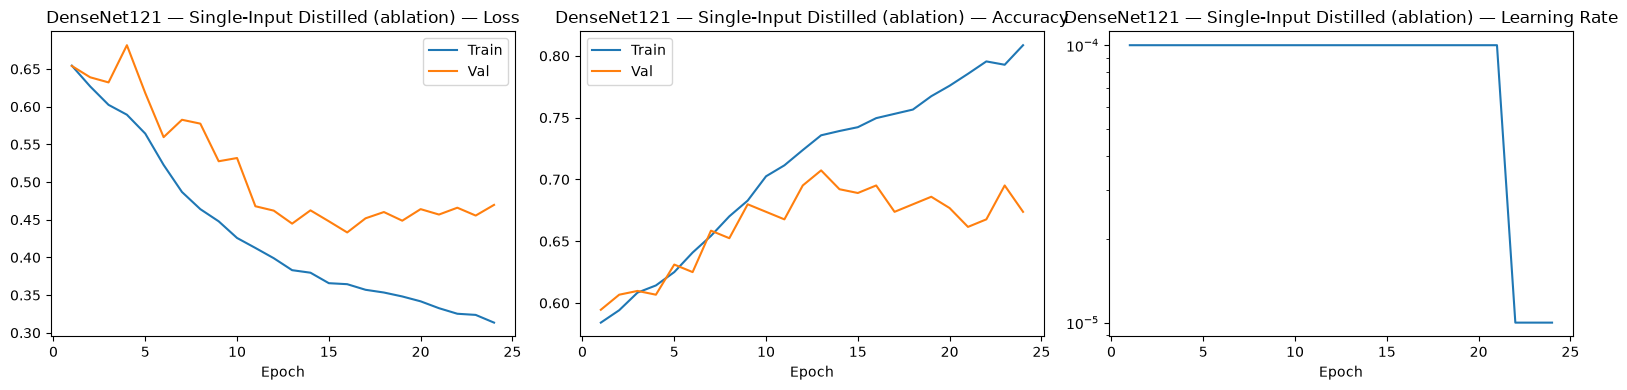

eval densenet121-test:   0%|          | 0/21 [00:00<?, ?it/s]

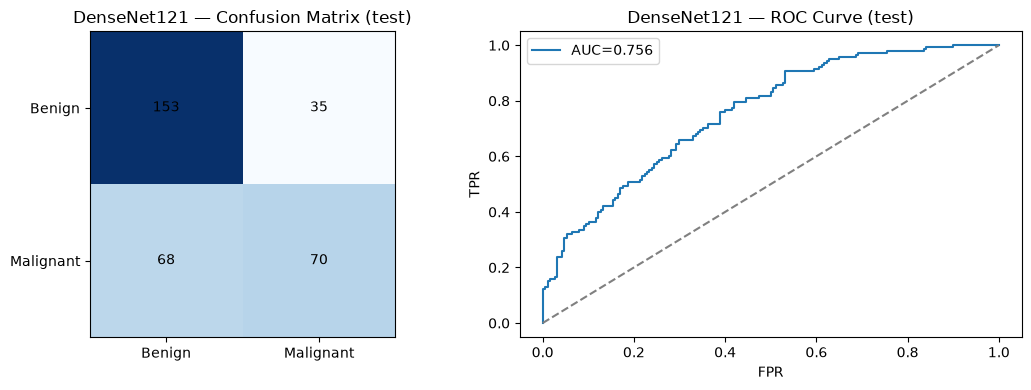

              precision    recall  f1-score   support

      Benign       0.69      0.81      0.75       188
   Malignant       0.67      0.51      0.58       138

    accuracy                           0.68       326
   macro avg       0.68      0.66      0.66       326
weighted avg       0.68      0.68      0.68       326


Experiment: stage0_singleinput_distilled_ablation_resnet50  (arch=resnet50)
head_lr=0.0001 backbone_lr=1e-05 weight_decay=0.0001 scheduler=plateau | distill T=4.0 alpha=0.5 | full unfreeze, no label smoothing


stage0_singleinput_distilled_ablation_resnet50 e1 [warmup-train]:   0%|          | 0/162 [00:00<?, ?it/s]

stage0_singleinput_distilled_ablation_resnet50 e1 [warmup-val]:   0%|          | 0/21 [00:00<?, ?it/s]

  [warmup] epoch  1 | train_loss 0.5361 acc 0.5868 | val_loss 0.5171 acc 0.5945


stage0_singleinput_distilled_ablation_resnet50 e2 [warmup-train]:   0%|          | 0/162 [00:00<?, ?it/s]

...

stage0_singleinput_distilled_ablation_resnet50 e23 [val]:   0%|          | 0/21 [00:00<?, ?it/s]

  epoch 23 | train_loss 0.3046 acc 0.7712 | val_loss 0.3838 acc 0.6951 | lr(head) 1.00e-05


stage0_singleinput_distilled_ablation_resnet50 e24 [train]:   0%|          | 0/162 [00:00<?, ?it/s]

stage0_singleinput_distilled_ablation_resnet50 e24 [val]:   0%|          | 0/21 [00:00<?, ?it/s]

  epoch 24 | train_loss 0.3015 acc 0.7685 | val_loss 0.3837 acc 0.6890 | lr(head) 1.00e-05
  Early stopping at epoch 24.


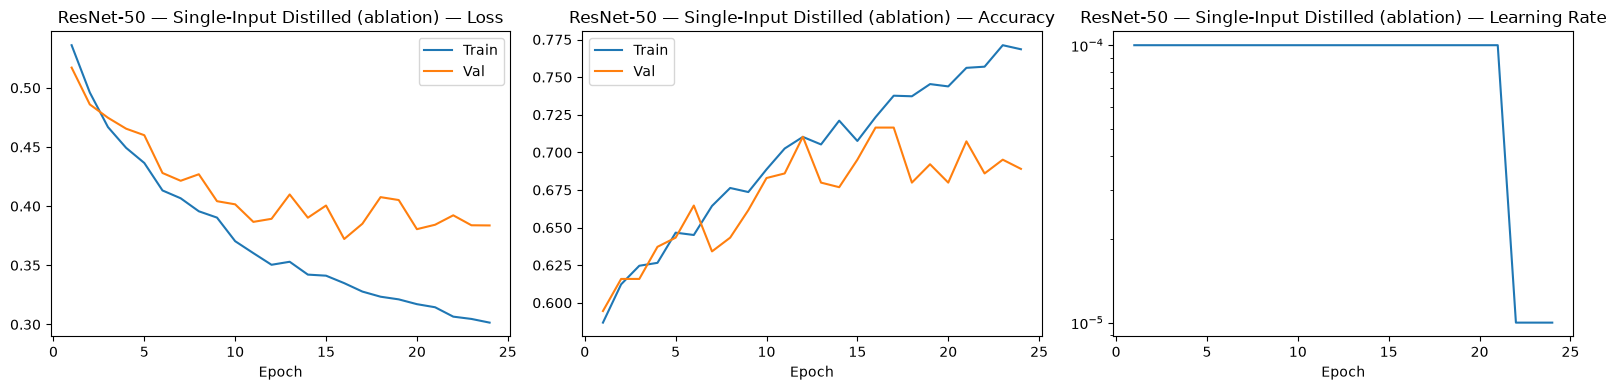

eval resnet50-test:   0%|          | 0/21 [00:00<?, ?it/s]

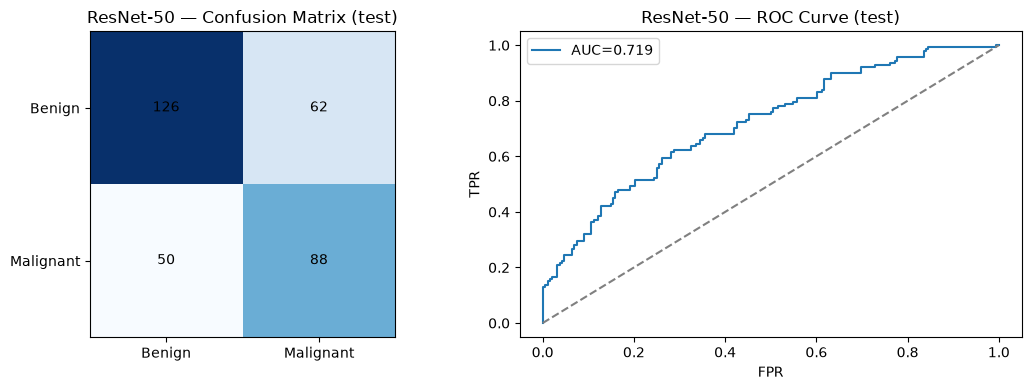

              precision    recall  f1-score   support

      Benign       0.72      0.67      0.69       188
   Malignant       0.59      0.64      0.61       138

    accuracy                           0.66       326
   macro avg       0.65      0.65      0.65       326
weighted avg       0.66      0.66      0.66       326


Experiment: stage0_singleinput_distilled_ablation_efficientnet_b2  (arch=efficientnet_b2)
head_lr=0.0001 backbone_lr=1e-05 weight_decay=0.0001 scheduler=plateau | distill T=4.0 alpha=0.5 | full unfreeze, no label smoothing


stage0_singleinput_distilled_ablation_efficientnet_b2 e1 [warmup-train]:   0%|          | 0/162 [00:00<?, ?it/…

stage0_singleinput_distilled_ablation_efficientnet_b2 e1 [warmup-val]:   0%|          | 0/21 [00:00<?, ?it/s]

  [warmup] epoch  1 | train_loss 0.5980 acc 0.5818 | val_loss 0.6356 acc 0.5945


stage0_singleinput_distilled_ablation_efficientnet_b2 e2 [warmup-train]:   0%|          | 0/162 [00:00<?, ?it/…

...

stage0_singleinput_distilled_ablation_efficientnet_b2 e28 [val]:   0%|          | 0/21 [00:00<?, ?it/s]

  epoch 28 | train_loss 0.3451 acc 0.7658 | val_loss 0.4652 acc 0.6982 | lr(head) 1.00e-05


stage0_singleinput_distilled_ablation_efficientnet_b2 e29 [train]:   0%|          | 0/162 [00:00<?, ?it/s]

stage0_singleinput_distilled_ablation_efficientnet_b2 e29 [val]:   0%|          | 0/21 [00:00<?, ?it/s]

  epoch 29 | train_loss 0.3336 acc 0.7828 | val_loss 0.4612 acc 0.7165 | lr(head) 1.00e-05
  Early stopping at epoch 29.


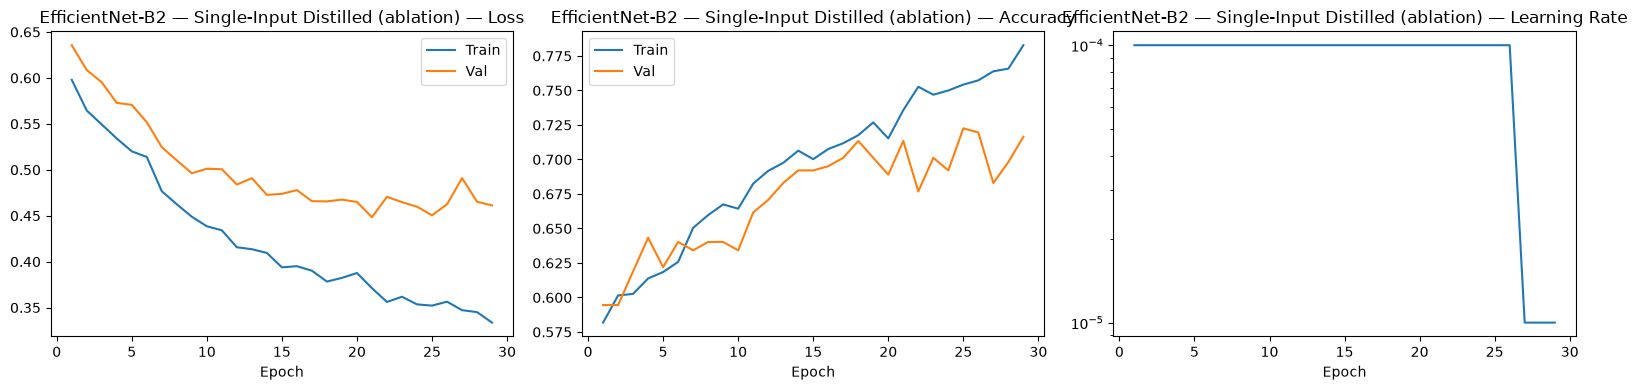

eval efficientnet_b2-test:   0%|          | 0/21 [00:00<?, ?it/s]

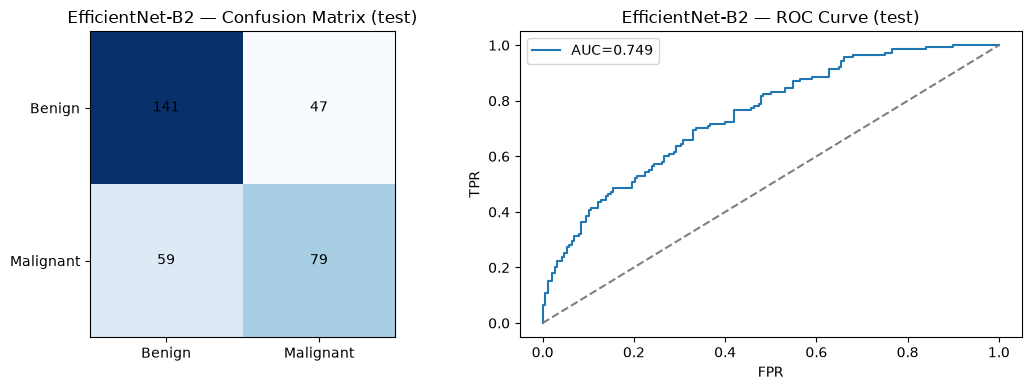

              precision    recall  f1-score   support

      Benign       0.70      0.75      0.73       188
   Malignant       0.63      0.57      0.60       138

    accuracy                           0.67       326
   macro avg       0.67      0.66      0.66       326
weighted avg       0.67      0.67      0.67       326


Experiment: stage0_singleinput_distilled_ablation_vgg16  (arch=vgg16)
head_lr=0.0001 backbone_lr=1e-05 weight_decay=0.0001 scheduler=plateau | distill T=4.0 alpha=0.5 | full unfreeze, no label smoothing


stage0_singleinput_distilled_ablation_vgg16 e1 [warmup-train]:   0%|          | 0/162 [00:00<?, ?it/s]

stage0_singleinput_distilled_ablation_vgg16 e1 [warmup-val]:   0%|          | 0/21 [00:00<?, ?it/s]

  [warmup] epoch  1 | train_loss 0.5550 acc 0.5949 | val_loss 0.6709 acc 0.5915


stage0_singleinput_distilled_ablation_vgg16 e2 [warmup-train]:   0%|          | 0/162 [00:00<?, ?it/s]

...

stage0_singleinput_distilled_ablation_vgg16 e23 [val]:   0%|          | 0/21 [00:00<?, ?it/s]

  epoch 23 | train_loss 0.2453 acc 0.8476 | val_loss 0.4314 acc 0.7043 | lr(head) 1.00e-05


stage0_singleinput_distilled_ablation_vgg16 e24 [train]:   0%|          | 0/162 [00:00<?, ?it/s]

stage0_singleinput_distilled_ablation_vgg16 e24 [val]:   0%|          | 0/21 [00:00<?, ?it/s]

  epoch 24 | train_loss 0.2444 acc 0.8511 | val_loss 0.4297 acc 0.7195 | lr(head) 1.00e-05
  Early stopping at epoch 24.


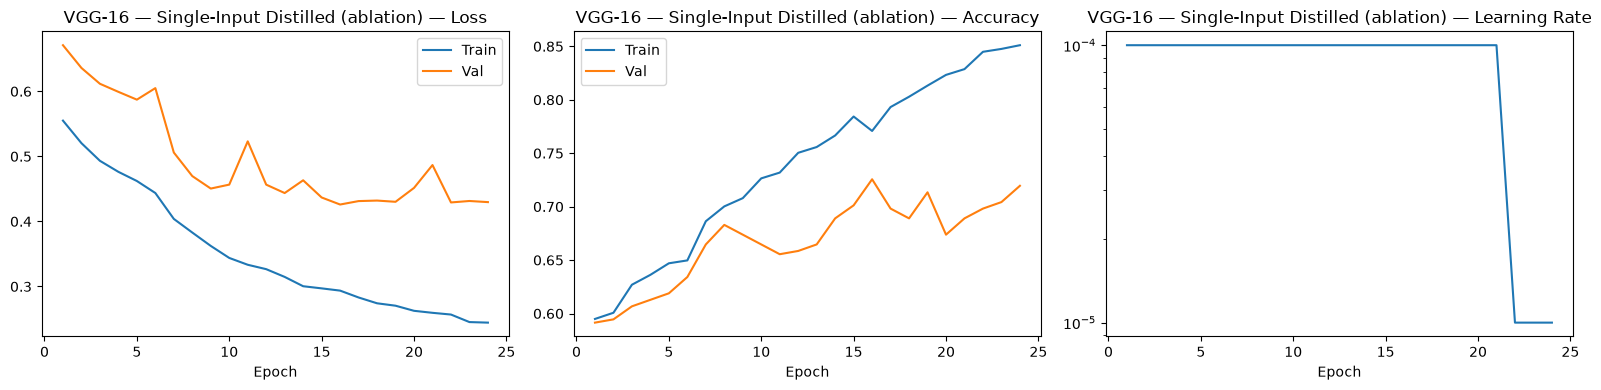

eval vgg16-test:   0%|          | 0/21 [00:00<?, ?it/s]

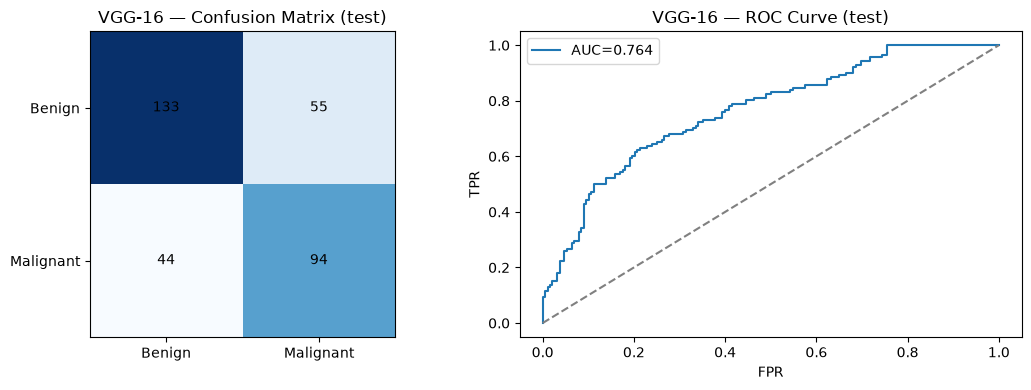

              precision    recall  f1-score   support

      Benign       0.75      0.71      0.73       188
   Malignant       0.63      0.68      0.66       138

    accuracy                           0.70       326
   macro avg       0.69      0.69      0.69       326
weighted avg       0.70      0.70      0.70       326

Saved test-set comparison metrics to results\single_input_distillation_ablation_test_metrics.csv


,model,architecture,accuracy,sensitivity,specificity,f1,roc_auc,best_val_accuracy,best_epoch,epochs_run,training_time_sec,checkpoint_path
0,DenseNet121,densenet121,0.684049,0.507246,0.813830,0.576132,0.755974,0.695122,16,24,1093.5,checkpoints\stage0_singleinput_distilled_ablat...
1,ResNet-50,resnet50,0.656442,0.637681,0.670213,0.611111,0.718702,0.716463,16,24,1055.8,checkpoints\stage0_singleinput_distilled_ablat...
2,EfficientNet-B2,efficientnet_b2,0.674847,0.572464,0.750000,0.598485,0.748998,0.713415,21,29,1102.2,checkpoints\stage0_singleinput_distilled_ablat...
3,VGG-16,vgg16,0.696319,0.681159,0.707447,0.655052,0.764184,0.725610,16,24,1711.0,checkpoints\stage0_singleinput_distilled_ablat...


In [9]:
train_loader, val_loader, test_loader = make_loaders()

ablation_results = []
ablation_histories = {}
ablation_test_evals = {}

for arch in ARCHITECTURES:
    display_name = ARCH_DISPLAY_NAMES[arch]
    exp_name = f"stage0_singleinput_distilled_ablation_{arch}"

    hist, ckpt, row = train_experiment(
        exp_name=exp_name, arch=arch,
        head_lr=BASELINE["head_lr"], backbone_lr=BASELINE["backbone_lr"],
        weight_decay=BASELINE["weight_decay"], scheduler_name=BASELINE["scheduler"],
        temperature=DISTILL_TEMPERATURE, alpha=DISTILL_ALPHA,
        train_loader=train_loader, val_loader=val_loader,
    )
    ablation_histories[arch] = hist
    plot_curves(hist, f"{display_name} — Single-Input Distilled (ablation)")

    test_eval = evaluate_checkpoint(row["checkpoint_path"], arch, test_loader, tag=f"{arch}-test")
    ablation_test_evals[arch] = test_eval
    plot_confusion_and_roc(test_eval, display_name)

    result_row = {
        "model": display_name,
        "architecture": arch,
        **test_eval["metrics"],
        "best_val_accuracy": row["best_val_accuracy"],
        "best_epoch": row["best_epoch"],
        "epochs_run": row["epochs_run"],
        "training_time_sec": row["training_time_sec"],
        "checkpoint_path": row["checkpoint_path"],
    }
    ablation_results.append(result_row)

ablation_df = pd.DataFrame(ablation_results)
ablation_csv_path = os.path.join(RESULTS_DIR, "single_input_distillation_ablation_test_metrics.csv")
ablation_df.to_csv(ablation_csv_path, index=False)
print(f"Saved test-set comparison metrics to {ablation_csv_path}")
ablation_df


## Comparison: distillation ablation vs. dual-input baseline vs. distillation-with-fixes (if run)

In [10]:
dual_input_df = pd.read_csv(os.path.join(RESULTS_DIR, "architecture_comparison_test_metrics.csv"))
with_fixes_path = os.path.join(RESULTS_DIR, "single_input_distilled_comparison_test_metrics.csv")
with_fixes_df = pd.read_csv(with_fixes_path) if os.path.exists(with_fixes_path) else None

comparison = ablation_df[["architecture", "model", "accuracy", "roc_auc"]].rename(
    columns={"accuracy": "distill_ablation_accuracy", "roc_auc": "distill_ablation_roc_auc"}
).merge(
    dual_input_df[["architecture", "accuracy", "roc_auc"]].rename(
        columns={"accuracy": "dual_input_accuracy", "roc_auc": "dual_input_roc_auc"}
    ),
    on="architecture",
)
comparison["accuracy_gap_vs_dual_input"] = (
    comparison["dual_input_accuracy"] - comparison["distill_ablation_accuracy"]
)
comparison["accuracy_gap_vs_85pct_target"] = 0.85 - comparison["distill_ablation_accuracy"]

if with_fixes_df is not None:
    comparison = comparison.merge(
        with_fixes_df[["architecture", "accuracy"]].rename(columns={"accuracy": "distill_with_fixes_accuracy"}),
        on="architecture", how="left",
    )

comparison


,architecture,model,distill_ablation_accuracy,distill_ablation_roc_auc,dual_input_accuracy,dual_input_roc_auc,accuracy_gap_vs_dual_input,accuracy_gap_vs_85pct_target
0,densenet121,DenseNet121,0.684049,0.755974,0.779141,0.861702,0.095092,0.165951
1,resnet50,ResNet-50,0.656442,0.718702,0.717791,0.796755,0.061350,0.193558
2,efficientnet_b2,EfficientNet-B2,0.674847,0.748998,0.769939,0.844743,0.095092,0.175153
3,vgg16,VGG-16,0.696319,0.764184,0.745399,0.834258,0.049080,0.153681
